In [ ]:
# t-SNE from predictions.json (predicted labels and embeddings) and labels.txt (true labels, one per line)

In [1]:
# load required libraries and functions
from sklearn.manifold import TSNE
from numpy import reshape
import seaborn as sns
import pandas as pd  
import numpy as np
import json
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
file = open('predictions.json', 'r')
data = json.load(file)
file.close()
num_features = len(data['0']['embeddings'][0])
print("num_features = " + str(num_features))
num_samples = len(data)
print("num_samples = " + str(num_samples))

num_features = 512
num_samples = 240


In [3]:
x = np.array([[0.0]*num_features]*num_samples)

In [4]:
for i in range(num_samples):
    for j in range(num_features):
        x[i][j] = data[str(i)]['embeddings'][0][j]

In [5]:
list_of_data = []
file2 = open('labels.txt', 'r')
for i in range(len(data)):
    current_line = file2.readline()
    current_list = current_line.split()
    list_of_data.append(current_list)
file2.close()

In [6]:
labels_as_ints = np.array([0]*len(data))
for i in range(len(data)):
    labels_as_ints[i] = int(list_of_data[i][0])

In [7]:
y = labels_as_ints

In [8]:
print(y.shape)
print(x.shape)

(240,)
(240, 512)


In [9]:
#3 D version


# t-SNE with 3 components
tsne = TSNE(n_components=3, verbose=1, random_state=23, learning_rate=10.0, perplexity=40.0)
z = tsne.fit_transform(x)

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 240 samples in 0.000s...
[t-SNE] Computed neighbors for 240 samples in 0.004s...
[t-SNE] Computed conditional probabilities for sample 240 / 240
[t-SNE] Mean sigma: 1.360784
[t-SNE] KL divergence after 250 iterations with early exaggeration: 41.668461
[t-SNE] KL divergence after 1000 iterations: 0.050657


In [10]:
# Create dataframe
df = pd.DataFrame()
df["y"] = y
df["comp-1"] = z[:,0]
df["comp-2"] = z[:,1]
df["comp-3"] = z[:,2]

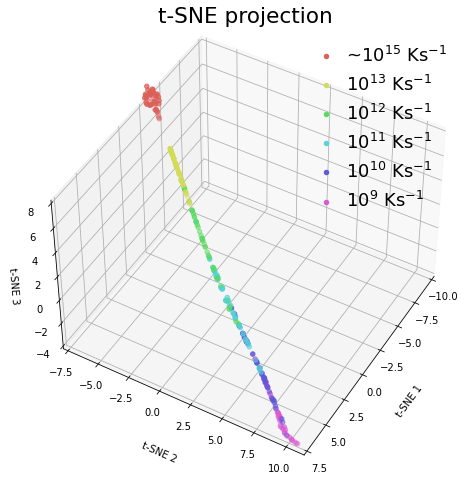

In [11]:
# Create color palette
palette = sns.color_palette("hls", len(np.unique(df.y)))

# Create figure and axis objects
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# setting font size to 30
plt.rcParams.update({'font.size': 18})

# Define custom labels for the classes
custom_labels = ['~$10^{15}$ Ks$^{-1}$', '$10^{13}$ Ks$^{-1}$', '$10^{12}$ Ks$^{-1}$', '$10^{11}$ Ks$^{-1}$', '$10^{10}$ Ks$^{-1}$', '$10^{9}$ Ks$^{-1}$']

# Plot each class separately with different colors
for label in np.unique(df.y):
    # Filter data of current class
    data_class = df[df.y == label]

    # Get color for this class
    color = palette[int(label)]

    # 3D scatter plot
    ax.scatter(data_class['comp-1'], data_class['comp-2'], data_class['comp-3'], color=color,\
              label=custom_labels[int(label)])

# Set title and labels
ax.set_title('t-SNE projection')
xlabel = ax.set_xlabel('t-SNE 1', labelpad=15)
ylabel = ax.set_ylabel('t-SNE 2', labelpad=15)
zlabel = ax.set_zlabel('t-SNE 3')


# # Apply new ticks
# ax.set_xticks(new_xticks)
ax.set_xticks([7.5, 5.0, 2.5, 0.0, -2.5, -5.0, -7.5, -10.0])
ax.set_yticks([-7.5, -5.0, -2.5, 0.0, 2.5, 5.0, 7.5, 10.0])


ax.set_zlim(-4, 8)
ax.set_ylim(-7.5, 11.0)


# Legend
ax.legend(handletextpad=0.1, framealpha=0.0)

# Rotate the plot
ax.view_init(elev=45, azim=30) #ChatGPT suggestion

# Save the plot as a PNG file
# plt.savefig('het_GANN-tSNE_7by7by7v4.png', dpi=600.0, transparent=True)

# Show the plot
plt.show()